## EDA( Exploratory Data Analysis )
 EDA is the process of examining, visualizing, and summarizing a dataset to understand its key characteristics before performing any modeling or advanced analysis.

#### IMPORT LIBRARIES

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency

#### LOAD THE DATASET AND DISPLAY INFORMATION

In [2]:
df = pd.read_csv('C:/Users/divyanshu/OneDrive/Desktop/Projects/ImpactSense/impactsenseAI-Infosys-Intern-project/milestone_2/week_3/Day_13/preprocessed_earthquake_data.csv')

print("Dataset Info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109848 entries, 0 to 109847
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   latitude          109848 non-null  float64
 1   longitude         109848 non-null  float64
 2   depth             109848 non-null  float64
 3   mag               109848 non-null  float64
 4   magType           109848 non-null  object 
 5   rms               109848 non-null  float64
 6   type              109848 non-null  object 
 7   status            109848 non-null  object 
 8   Year              109848 non-null  int64  
 9   Month             109848 non-null  int64  
 10  Day               109848 non-null  int64  
 11  Hour              109848 non-null  int64  
 12  Minute            109848 non-null  int64  
 13  Second            109848 non-null  int64  
 14  DayOfWeek         109848 non-null  int64  
 15  Mw                109715 non-null  float64
 16  damage

In [3]:
# Combine separate time components (Year, Month, Day, Hour, Minute, Second) into a single datetime column 

time_cols = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']
available_cols = [col for col in time_cols if col in df.columns]

if {'Year', 'Month', 'Day'}.issubset(df.columns):
    df['datetime'] = pd.to_datetime(df[['Year', 'Month', 'Day']].astype(str).agg('-'.join, axis=1), errors='coerce')
elif 'Date' in df.columns:
    df['datetime'] = pd.to_datetime(df['Date'], errors='coerce')
else:
    raise ValueError("No recognizable time columns found.")

#### Task 1. Temporal Distribution Analysis
Analyze earthquake frequency and magnitude trends over time.


In [4]:
# Earthquake frequency by Year, Month, DayOfWeek
yearly_counts = df['Year'].value_counts().sort_index()
monthly_counts = df['Month'].value_counts()
weekday_counts = df['DayOfWeek'].value_counts()


# Mean magnitude and damage potential by temporal dimensions
df['Year'] = df['datetime'].dt.year
df['Month'] = df['datetime'].dt.month_name()
df['DayOfWeek'] = df['datetime'].dt.day_name()

# Identify magnitude and damage columns
magnitude_col = next((col for col in df.columns if 'mag' in col.lower()), None)
damage_col = next((col for col in df.columns if 'damage_potential' in col.lower()), None)

# --- Frequency analysis ---
yearly_counts = df['Year'].value_counts().sort_index()
monthly_counts = df['Month'].value_counts()[
    ['January','February','March','April','May','June','July','August','September','October','November','December']
]
weekday_counts = df['DayOfWeek'].value_counts()[
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
]

temporal_summary = {}
if magnitude_col:
    temporal_summary['Year'] = df.groupby('Year')[magnitude_col].mean()
    temporal_summary['Month'] = df.groupby('Month')[magnitude_col].mean()
    temporal_summary['DayOfWeek'] = df.groupby('DayOfWeek')[magnitude_col].mean()

if damage_col:
    temporal_summary['Year_damage'] = df.groupby('Year')[damage_col].mean()


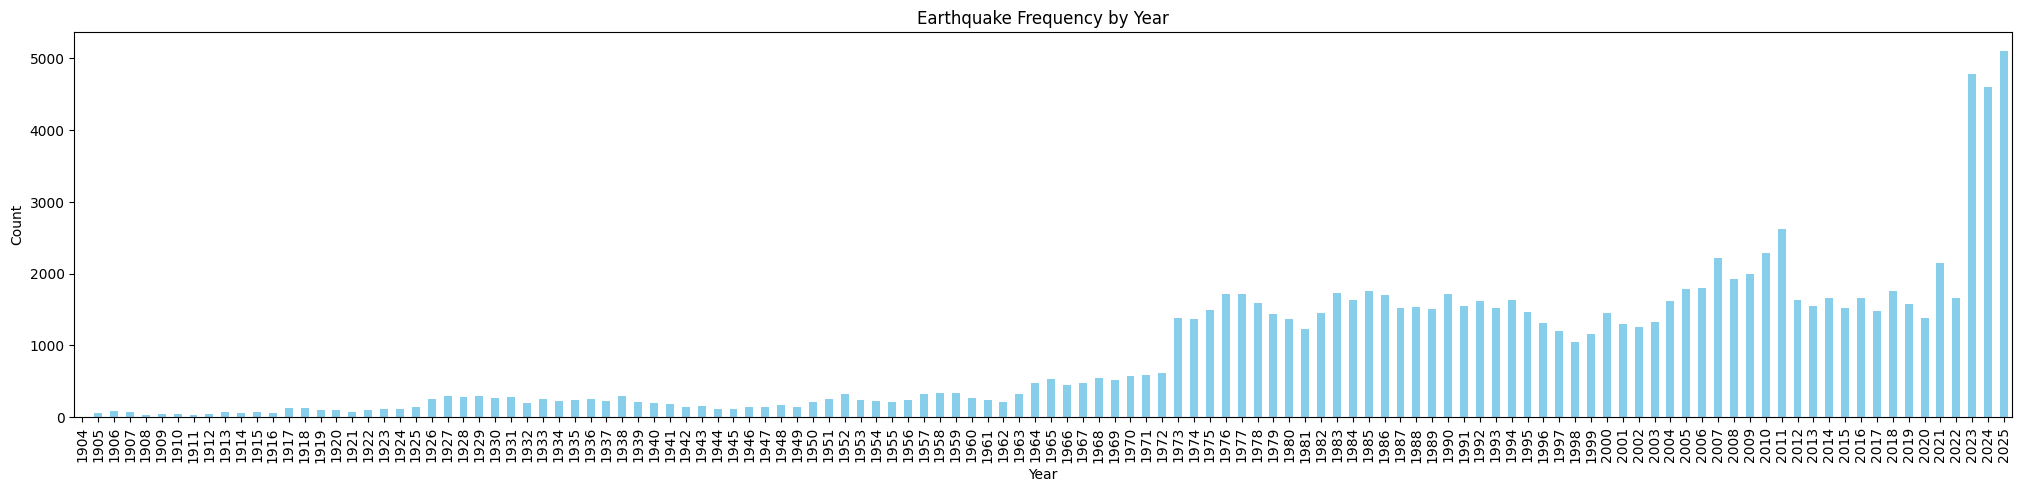

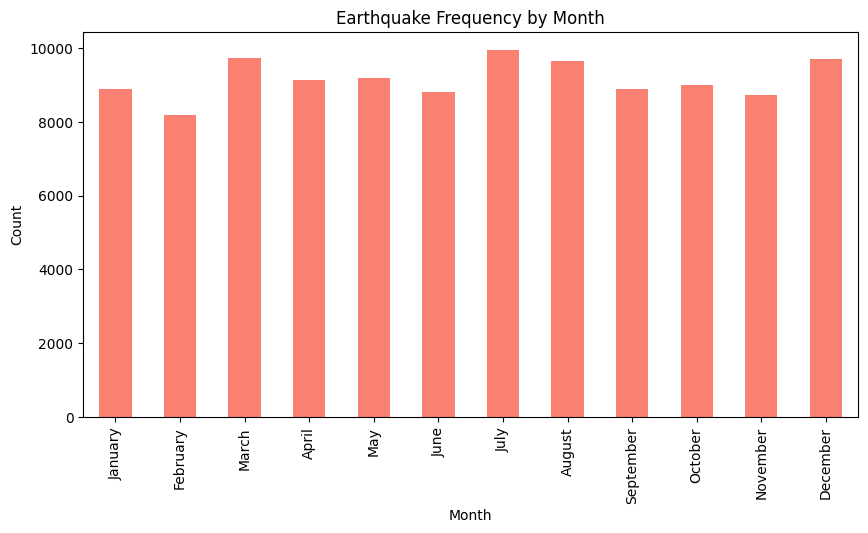

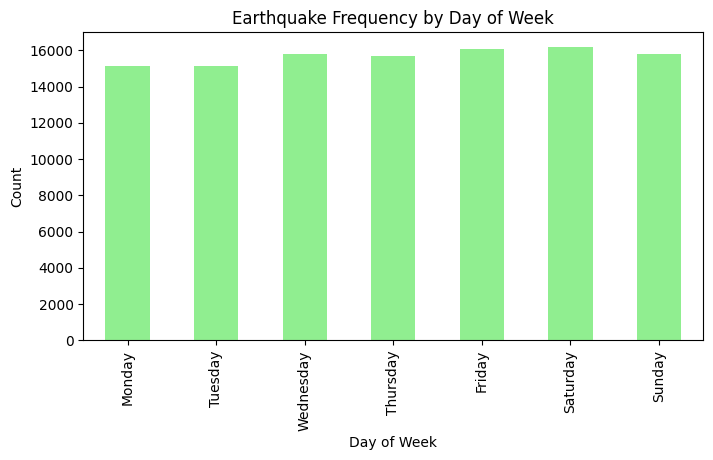

In [5]:
plt.figure(figsize=(25, 5))
yearly_counts.plot(kind='bar', color='skyblue')
plt.title('Earthquake Frequency by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
df['Month'].value_counts().reindex(month_order).plot(kind='bar', color='salmon')
plt.title('Earthquake Frequency by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 4))
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['DayOfWeek'].value_counts().reindex(weekday_order).plot(kind='bar', color='lightgreen')
plt.title('Earthquake Frequency by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.show()

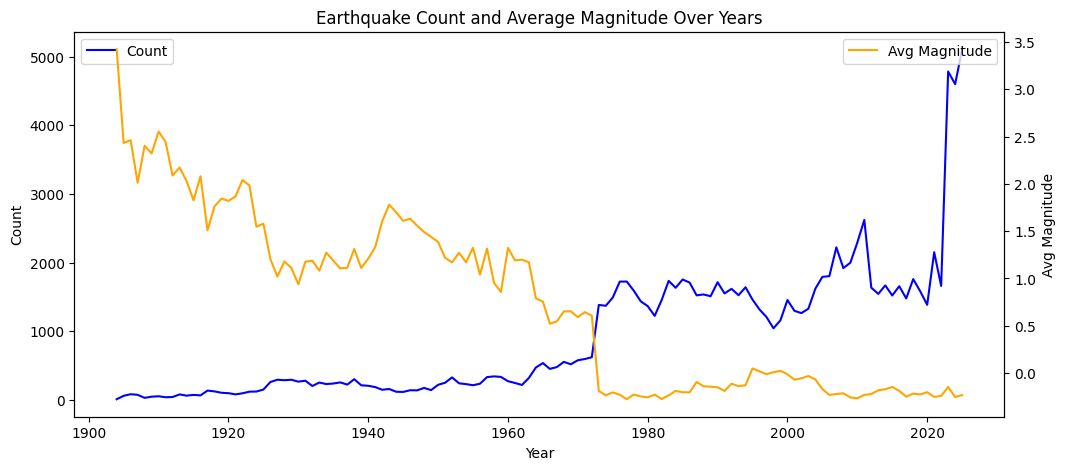

In [6]:
# Time series of earthquake counts and average magnitude by year
plt.figure(figsize=(12,5))
ax = df.groupby('Year').size().plot(label='Count', color='blue')
ax2 = ax.twinx()
df.groupby('Year')[magnitude_col].mean().plot(ax=ax2, color='orange', label='Avg Magnitude')
ax.set_ylabel('Count')
ax2.set_ylabel('Avg Magnitude')
ax.set_title('Earthquake Count and Average Magnitude Over Years')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

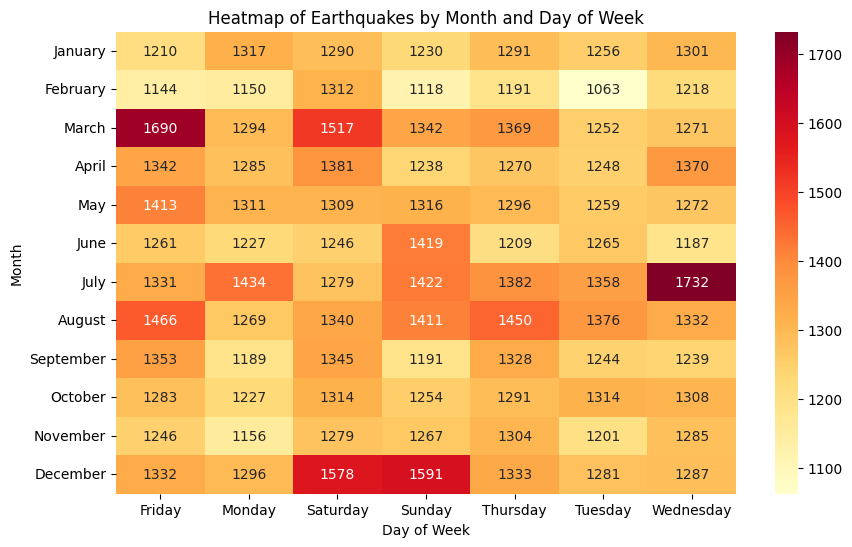

In [7]:
#  Heatmap of earthquakes by Month and DayOfWeek
heat_data = df.groupby(['Month','DayOfWeek']).size().unstack(fill_value=0)
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
heat_data = heat_data.reindex(month_order)

plt.figure(figsize=(10,6))
sns.heatmap(heat_data, cmap='YlOrRd', annot=True, fmt='d')
plt.title('Heatmap of Earthquakes by Month and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Month')
plt.show()

In [8]:
print("\nYearly Mean Magnitude:")
print(temporal_summary['Year'])

if damage_col:
    print("\nYearly Mean Damage Potential:")
    print(temporal_summary['Year_damage'])


Yearly Mean Magnitude:
Year
1904    3.424619
1905    2.433381
1906    2.462752
1907    2.012222
1908    2.403293
          ...   
2021   -0.253093
2022   -0.242423
2023   -0.147624
2024   -0.255237
2025   -0.233389
Name: mag, Length: 122, dtype: float64

Yearly Mean Damage Potential:
Year
1904    10.000000
1905    10.000000
1906     9.984457
1907     9.959922
1908    10.000000
          ...    
2021     9.571241
2022     9.445189
2023     9.393469
2024     9.361794
2025     9.619677
Name: damage_potential, Length: 122, dtype: float64


#### Task 2: Geographical Distribution Analysis
Explore spatial patterns of earthquake epicenters

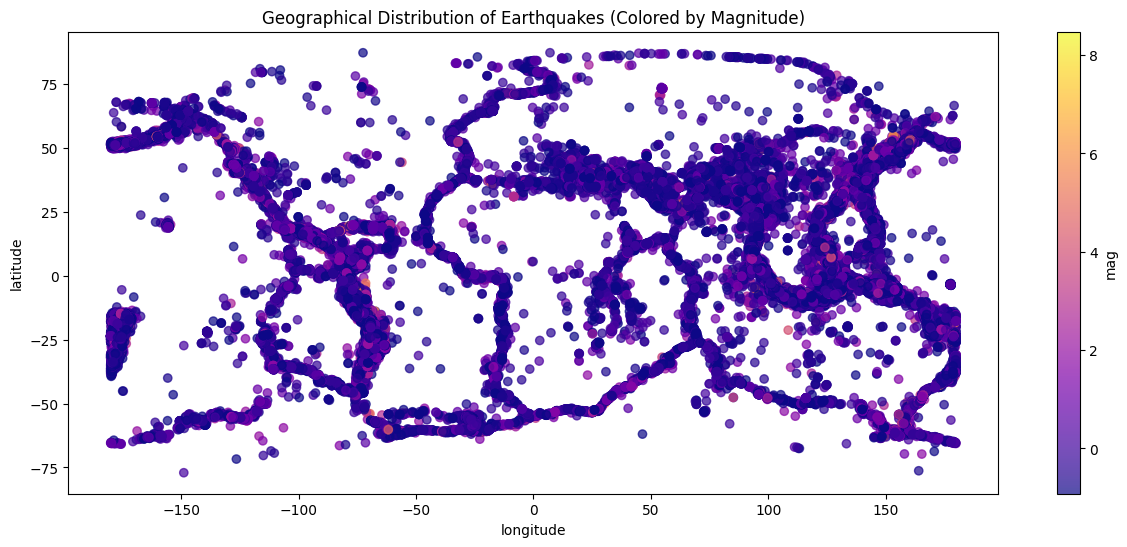

In [9]:
# Create scatter plot for latitude vs longitude colored by magnitude
plt.figure(figsize=(15, 6))
scatter = plt.scatter(
    df['longitude'], 
    df['latitude'], 
    c=df['mag'], 
    cmap='plasma', 
    alpha=0.7
)

plt.colorbar(scatter, label='mag')
plt.title('Geographical Distribution of Earthquakes (Colored by Magnitude)')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.show()

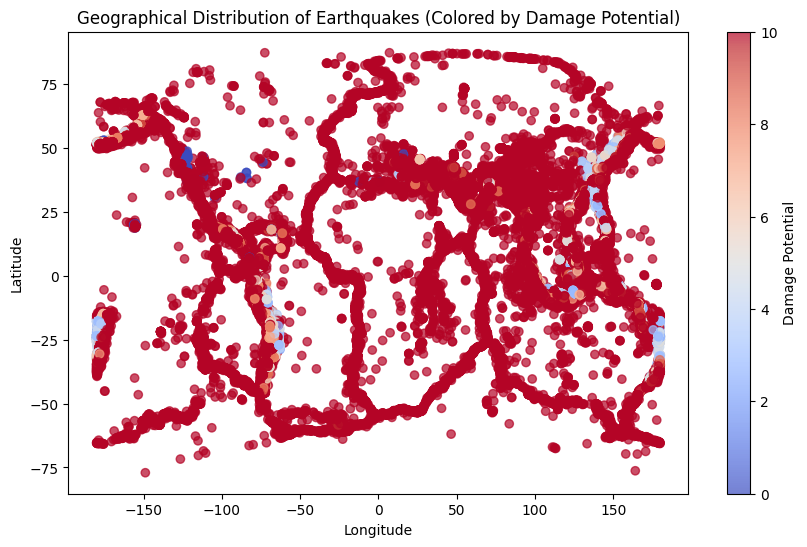

In [10]:
# Create scatter plot for latitude vs longitude colored by damage potential

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['longitude'], 
    df['latitude'], 
    c=df['damage_potential'], 
    cmap='coolwarm', 
    alpha=0.7
)

plt.colorbar(scatter, label='Damage Potential')
plt.title('Geographical Distribution of Earthquakes (Colored by Damage Potential)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

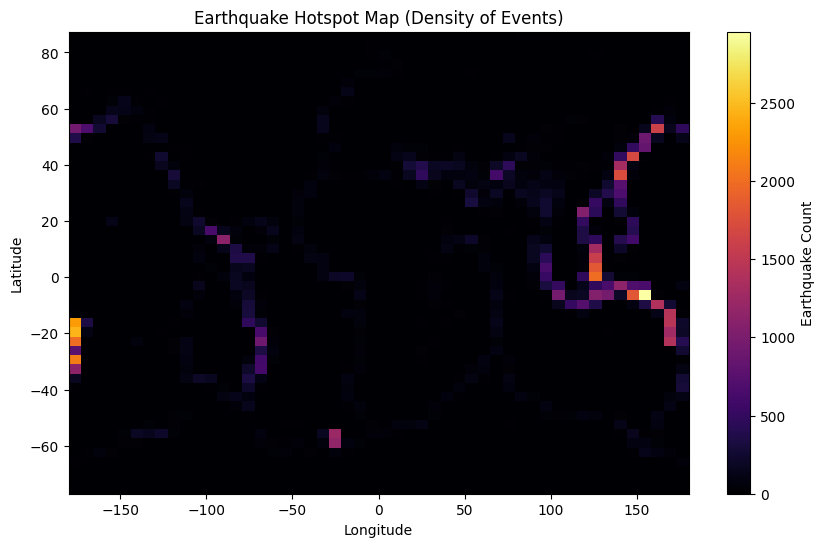

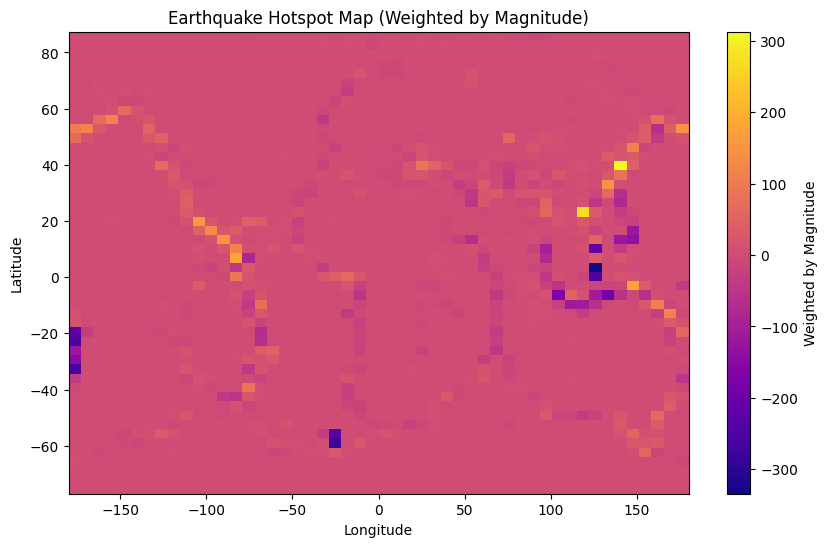

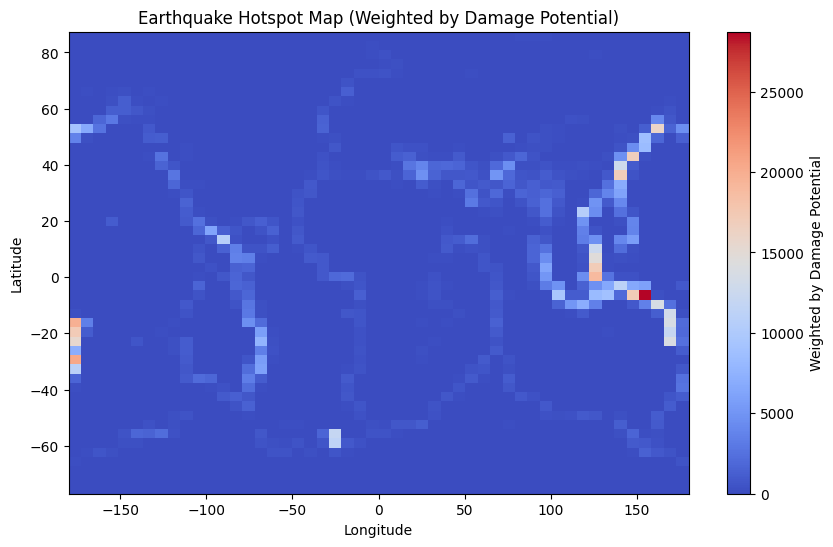

In [11]:
# 2D Histogram by Frequency

plt.figure(figsize=(10, 6))
plt.hist2d(
    df['longitude'], 
    df['latitude'], 
    bins=(50, 50),         # number of grid bins for density
    cmap='inferno'         # color map representing density
)
plt.colorbar(label='Earthquake Count')
plt.title('Earthquake Hotspot Map (Density of Events)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


# Weighted 2D Histogram by Magnitude

# This highlights areas with both high frequency AND higher magnitudes.
plt.figure(figsize=(10, 6))
plt.hist2d(
    df['longitude'], 
    df['latitude'], 
    bins=(50, 50),
    weights=df['mag'],  # weight each point by its magnitude
    cmap='plasma'
)
plt.colorbar(label='Weighted by Magnitude')
plt.title('Earthquake Hotspot Map (Weighted by Magnitude)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Weighted 2D Histogram by Damage Potential

# This highlights high-risk zones (high damage potential).
plt.figure(figsize=(10, 6))
plt.hist2d(
    df['longitude'], 
    df['latitude'], 
    bins=(50, 50),
    weights=df['damage_potential'],  # weight by damage potential
    cmap='coolwarm'
)
plt.colorbar(label='Weighted by Damage Potential')
plt.title('Earthquake Hotspot Map (Weighted by Damage Potential)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [12]:
#  Create Latitude and Longitude Bins

# Divide the globe (or dataset coverage) into evenly spaced bins
lat_bins = np.arange(df['latitude'].min(), df['latitude'].max(), 5)
lon_bins = np.arange(df['longitude'].min(), df['longitude'].max(), 5)

# Categorize each earthquake into a lat/lon region
df['Lat_Bin'] = pd.cut(df['latitude'], bins=lat_bins)
df['Lon_Bin'] = pd.cut(df['longitude'], bins=lon_bins)

#  Compute Summary Statistics for Each Region

region_summary = (
    df.groupby(['Lat_Bin', 'Lon_Bin'])
    .agg(
        Earthquake_Count=('mag', 'count'),
        Mean_Magnitude=('mag', 'mean'),
        Mean_Damage_Potential=('damage_potential', 'mean')
    )
    .reset_index()
)

# Display top 10 regions for preview
print(region_summary.head(10))


            Lat_Bin               Lon_Bin  Earthquake_Count  Mean_Magnitude  \
0  (-77.08, -72.08]  (-179.997, -174.997]                 0             NaN   
1  (-77.08, -72.08]  (-174.997, -169.997]                 0             NaN   
2  (-77.08, -72.08]  (-169.997, -164.997]                 0             NaN   
3  (-77.08, -72.08]  (-164.997, -159.997]                 0             NaN   
4  (-77.08, -72.08]  (-159.997, -154.997]                 0             NaN   
5  (-77.08, -72.08]  (-154.997, -149.997]                 0             NaN   
6  (-77.08, -72.08]  (-149.997, -144.997]                 0             NaN   
7  (-77.08, -72.08]  (-144.997, -139.997]                 0             NaN   
8  (-77.08, -72.08]  (-139.997, -134.997]                 0             NaN   
9  (-77.08, -72.08]  (-134.997, -129.997]                 0             NaN   

   Mean_Damage_Potential  
0                    NaN  
1                    NaN  
2                    NaN  
3                    N

C:\Users\divyanshu\AppData\Local\Temp\ipykernel_20028\222508550.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Lat_Bin', 'Lon_Bin'])


C:\Users\divyanshu\AppData\Local\Temp\ipykernel_20028\4036856205.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = region_summary.pivot_table(


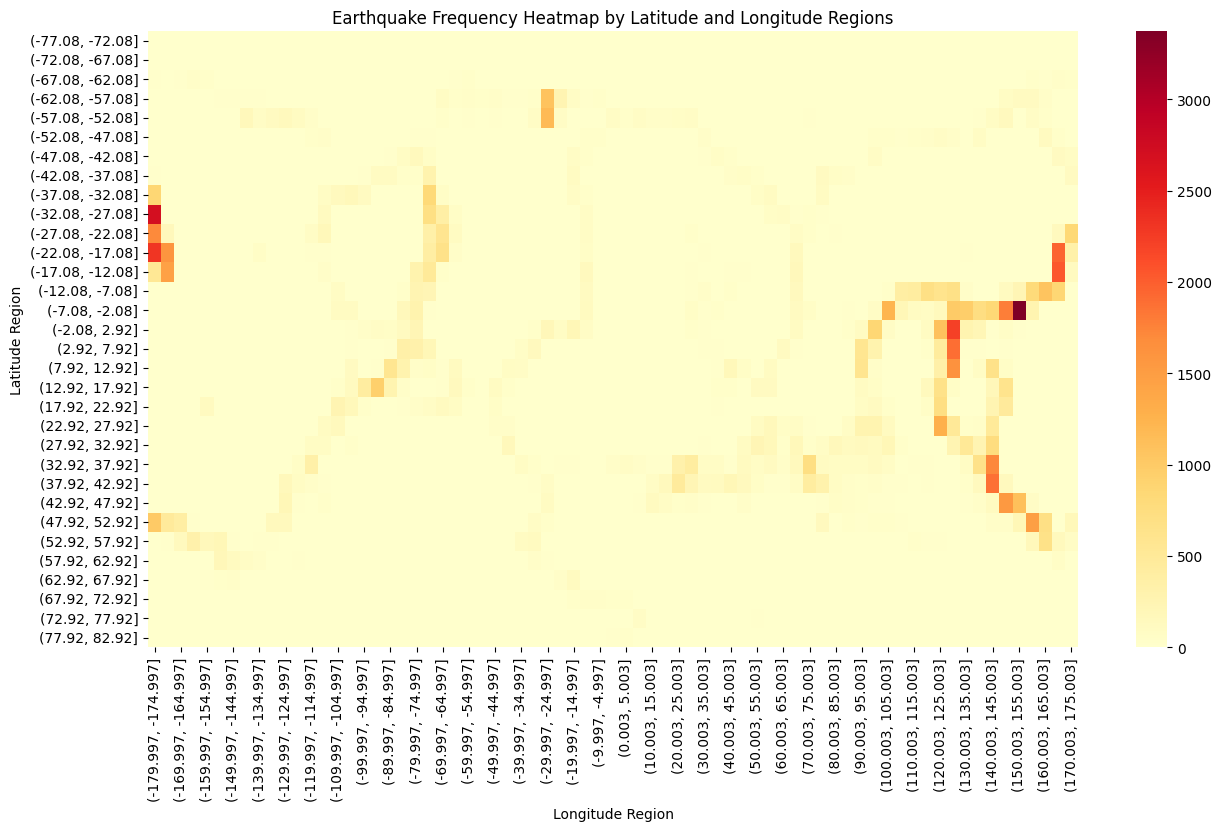

In [13]:
 # Visualize Earthquake Density by Region (Heatmap)

pivot_table = region_summary.pivot_table(
    index='Lat_Bin', columns='Lon_Bin', values='Earthquake_Count', fill_value=0
)

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_table, cmap='YlOrRd')
plt.title('Earthquake Frequency Heatmap by Latitude and Longitude Regions')
plt.xlabel('Longitude Region')
plt.ylabel('Latitude Region')
plt.show()

C:\Users\divyanshu\AppData\Local\Temp\ipykernel_20028\3692579634.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_mag = region_summary.pivot_table(


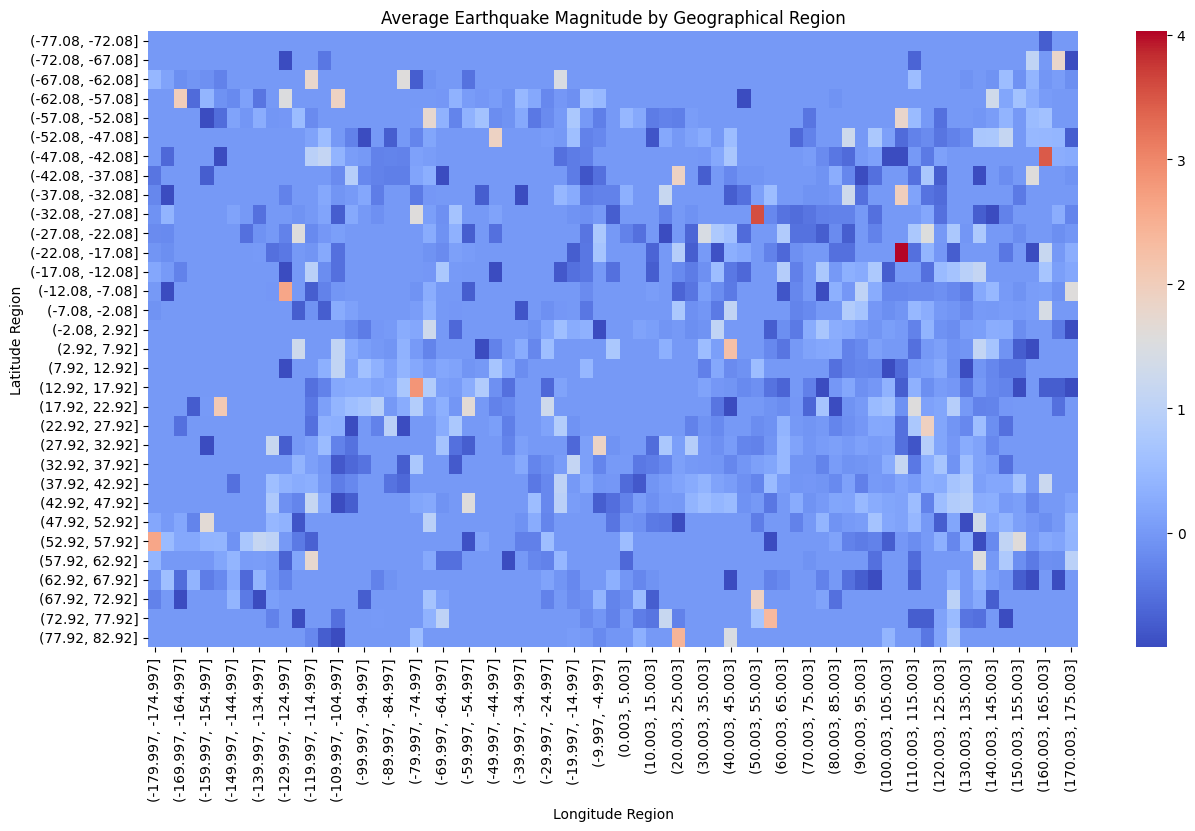

In [14]:
#  Visualize Average Magnitude by Region

pivot_mag = region_summary.pivot_table(
    index='Lat_Bin', columns='Lon_Bin', values='Mean_Magnitude', fill_value=0
)

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_mag, cmap='coolwarm')
plt.title('Average Earthquake Magnitude by Geographical Region')
plt.xlabel('Longitude Region')
plt.ylabel('Latitude Region')
plt.show()


C:\Users\divyanshu\AppData\Local\Temp\ipykernel_20028\1483301182.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_damage = region_summary.pivot_table(


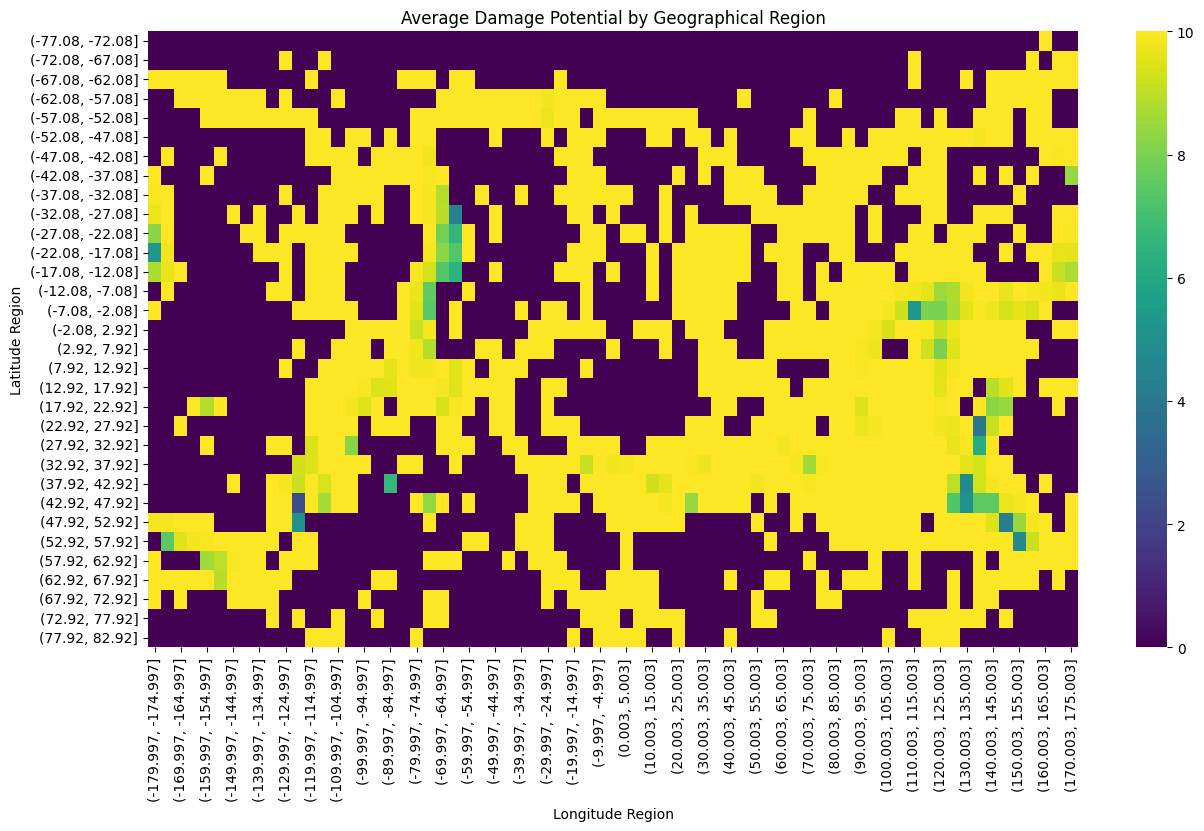

In [15]:
# Visualize Average Damage Potential by Region

pivot_damage = region_summary.pivot_table(
    index='Lat_Bin', columns='Lon_Bin', values='Mean_Damage_Potential', fill_value=0
)

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_damage, cmap='viridis')
plt.title('Average Damage Potential by Geographical Region')
plt.xlabel('Longitude Region')
plt.ylabel('Latitude Region')
plt.show()


Correlation Matrix:
                  latitude  longitude       mag  damage_potential
latitude          1.000000   0.213085  0.044229          0.098566
longitude         0.213085   1.000000 -0.002900          0.093421
mag               0.044229  -0.002900  1.000000          0.031456
damage_potential  0.098566   0.093421  0.031456          1.000000


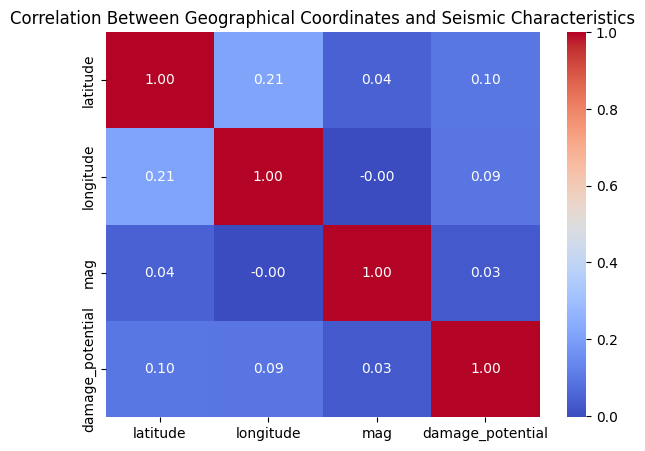

In [16]:
#  Compute Correlation Matrix

corr_matrix = df[['latitude', 'longitude', 'mag', 'damage_potential']].corr()

print("\nCorrelation Matrix:")
print(corr_matrix)


#  Visualize Correlation Matrix (Heatmap)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Geographical Coordinates and Seismic Characteristics')
plt.show()

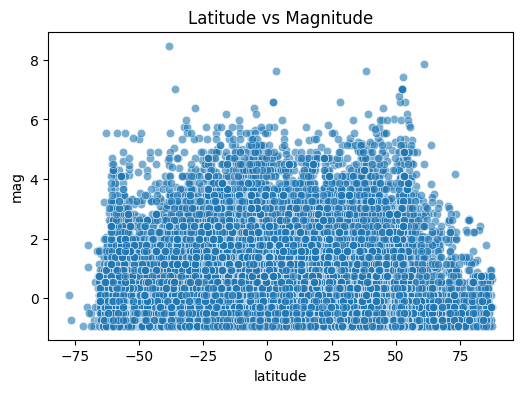

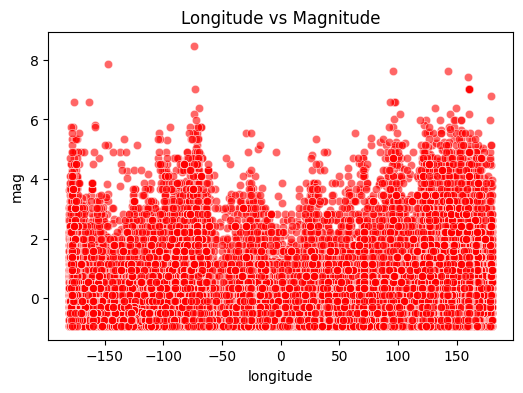

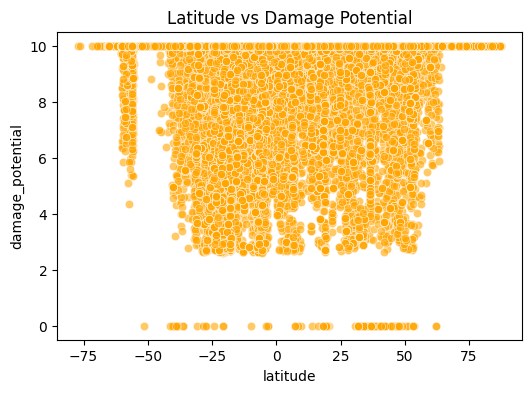

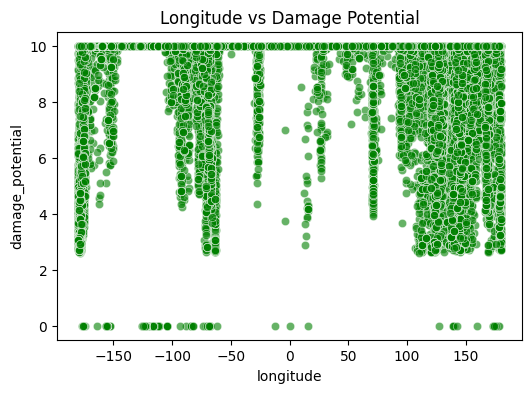

In [17]:
# Latitude vs Magnitude
plt.figure(figsize=(6, 4))
sns.scatterplot(x='latitude', y='mag', data=df, alpha=0.6)
plt.title('Latitude vs Magnitude')
plt.show()

# Longitude vs Magnitude
plt.figure(figsize=(6, 4))
sns.scatterplot(x='longitude', y='mag', data=df, alpha=0.6 , color="red")
plt.title('Longitude vs Magnitude')
plt.show()

# Latitude vs Damage Potential
plt.figure(figsize=(6, 4))
sns.scatterplot(x='latitude', y='damage_potential', data=df, alpha=0.6, color='orange')
plt.title('Latitude vs Damage Potential')
plt.show()

# Longitude vs Damage Potential
plt.figure(figsize=(6, 4))
sns.scatterplot(x='longitude', y='damage_potential', data=df, alpha=0.6, color='green')
plt.title('Longitude vs Damage Potential')
plt.show()

In [18]:
# Bin by Geographic Regions

lat_bins = np.arange(df['latitude'].min(), df['latitude'].max(), 5)
lon_bins = np.arange(df['longitude'].min(), df['longitude'].max(), 5)

df['Lat_Bin'] = pd.cut(df['latitude'], bins=lat_bins)
df['Lon_Bin'] = pd.cut(df['longitude'], bins=lon_bins)

 # Compute Average Damage Potential per Region

risk_summary = (
    df.groupby(['Lat_Bin', 'Lon_Bin'])
    .agg(
        Mean_Damage_Potential=('damage_potential', 'mean'),
        Mean_Magnitude=('mag', 'mean'),
        Event_Count=('damage_potential', 'count')
    )
    .reset_index()
)

print("Top 10 High-Risk Regions:")
print(risk_summary.sort_values(by='Mean_Damage_Potential', ascending=False).head(10))

Top 10 High-Risk Regions:
               Lat_Bin               Lon_Bin  Mean_Damage_Potential  \
212   (-67.08, -62.08]    (170.003, 175.003]                   10.0   
2262    (77.92, 82.92]    (125.003, 130.003]                   10.0   
68    (-77.08, -72.08]    (160.003, 165.003]                   10.0   
81    (-72.08, -67.08]  (-129.997, -124.997]                   10.0   
84    (-72.08, -67.08]  (-114.997, -109.997]                   10.0   
129   (-72.08, -67.08]    (110.003, 115.003]                   10.0   
138   (-72.08, -67.08]    (155.003, 160.003]                   10.0   
140   (-72.08, -67.08]    (165.003, 170.003]                   10.0   
141   (-72.08, -67.08]    (170.003, 175.003]                   10.0   
142   (-67.08, -62.08]  (-179.997, -174.997]                   10.0   

      Mean_Magnitude  Event_Count  
212        -0.129226           30  
2262        0.787469            6  
68         -0.712513            1  
81         -0.921328            1  
84         -

C:\Users\divyanshu\AppData\Local\Temp\ipykernel_20028\2569605431.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Lat_Bin', 'Lon_Bin'])


C:\Users\divyanshu\AppData\Local\Temp\ipykernel_20028\1076084653.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_risk = risk_summary.pivot_table(


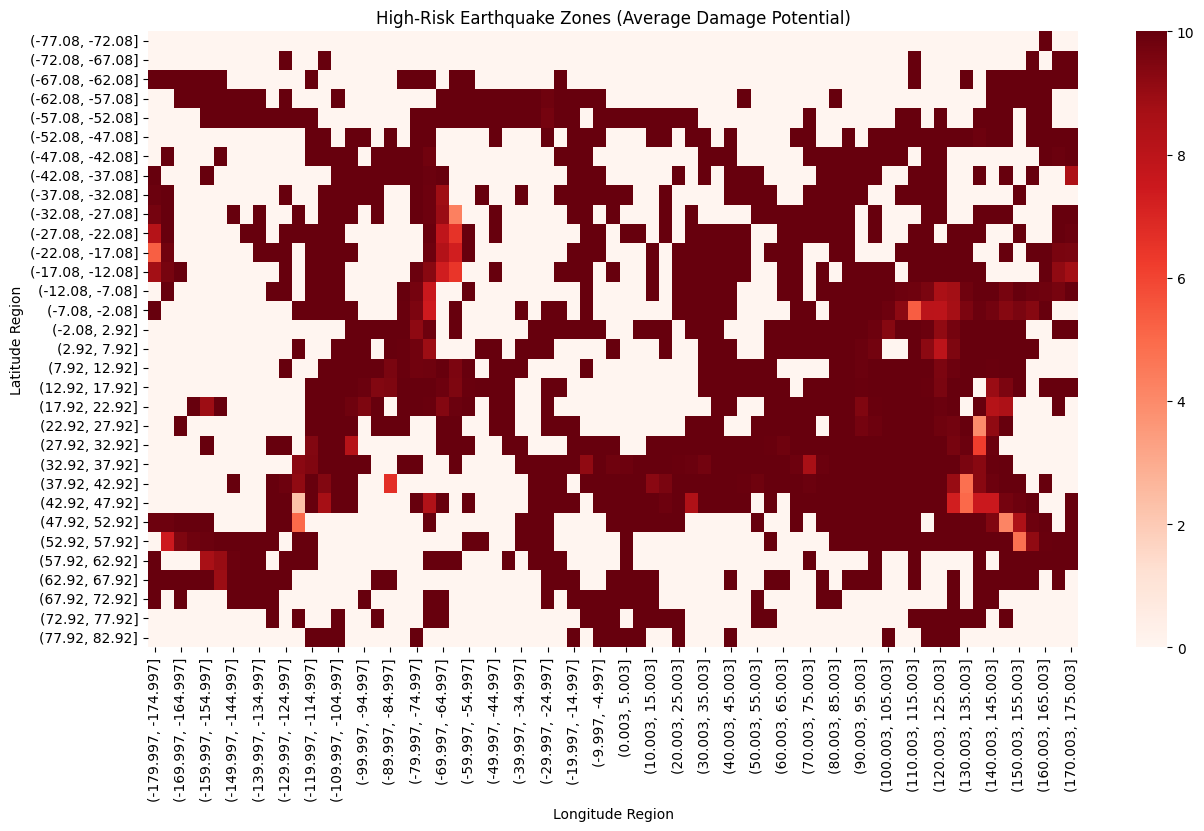

In [19]:
# Heatmap: Average Damage Potential by Region

pivot_risk = risk_summary.pivot_table(
    index='Lat_Bin', columns='Lon_Bin', values='Mean_Damage_Potential', fill_value=0
)

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_risk, cmap='Reds')
plt.title('High-Risk Earthquake Zones (Average Damage Potential)')
plt.xlabel('Longitude Region')
plt.ylabel('Latitude Region')
plt.show()

#### Task 3: Magnitude and Damage Potential Relationship
 Analyze the relationship between earthquake magnitude and damage potential.

In [20]:
# Firstly we will ensure required columns exist

required_cols = ['mag', 'damage_potential', 'depth']
if not all(col in df.columns for col in required_cols):
    raise ValueError(f"Dataset missing one of these columns: {required_cols}")

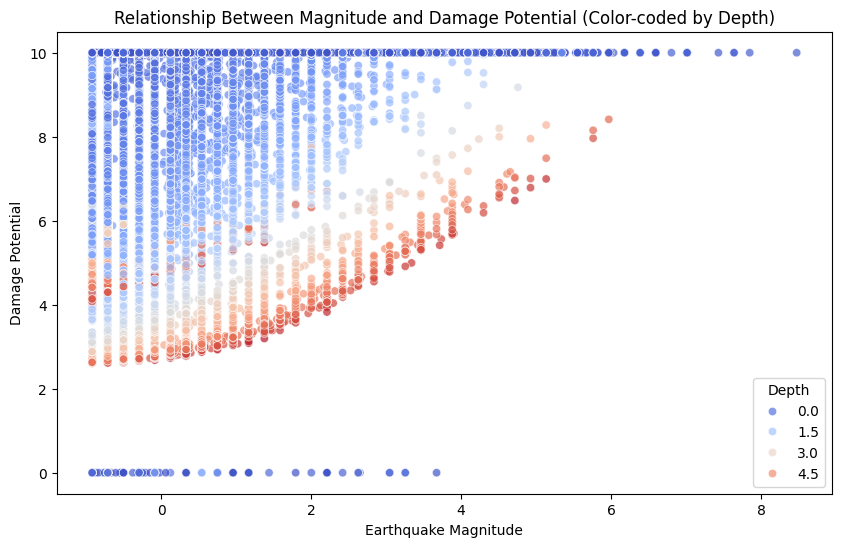

In [21]:
# Scatter Plot: Magnitude vs Damage Potential

plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=df,
    x='mag',
    y='damage_potential',
    hue='depth',            # Color-coded by depth
    palette='coolwarm',     # Depth gradient color
    alpha=0.7
)
plt.title('Relationship Between Magnitude and Damage Potential (Color-coded by Depth)')
plt.xlabel('Earthquake Magnitude')
plt.ylabel('Damage Potential')
plt.legend(title='Depth')
plt.show()

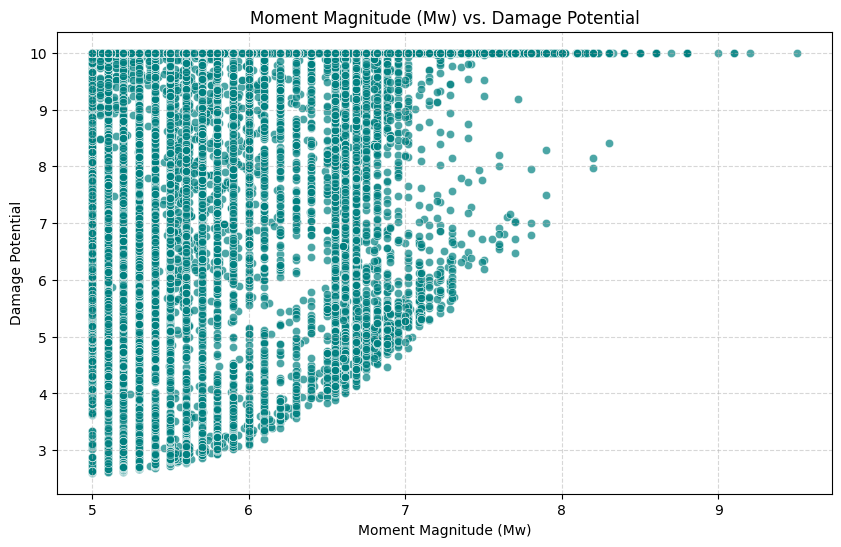

In [22]:
# Ensure required columns exist

required_cols = ['Mw', 'damage_potential']
if not all(col in df.columns for col in required_cols):
    raise ValueError(f"Dataset missing one of these columns: {required_cols}")


# Scatter Plot: Mw vs Damage Potential

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Mw', 
    y='damage_potential',
    color='teal',
    alpha=0.7
)
plt.title('Moment Magnitude (Mw) vs. Damage Potential')
plt.xlabel('Moment Magnitude (Mw)')
plt.ylabel('Damage Potential')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

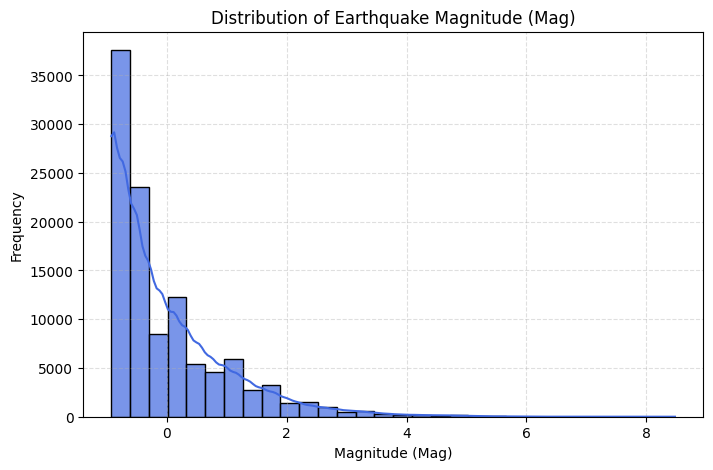

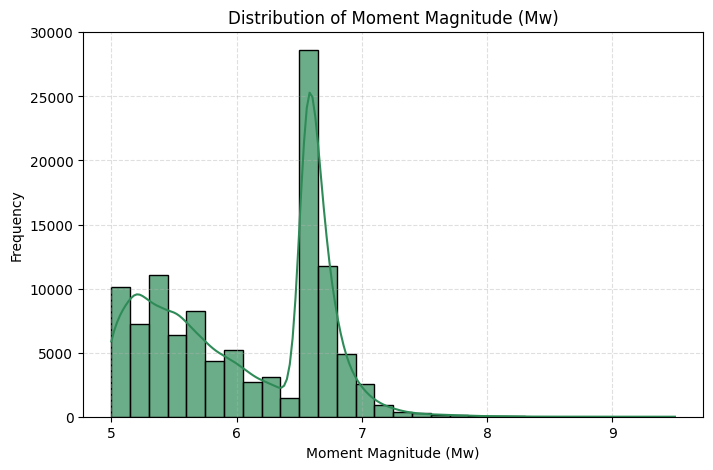

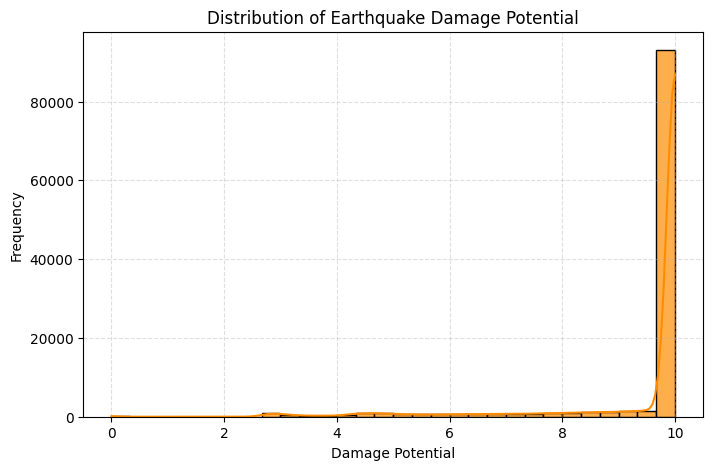

In [23]:
 # Distribution of 'mag'

plt.figure(figsize=(8, 5))
sns.histplot(df['mag'], kde=True, bins=30, color='royalblue', alpha=0.7)
plt.title('Distribution of Earthquake Magnitude (Mag)')
plt.xlabel('Magnitude (Mag)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# Distribution of 'Mw' (Moment Magnitude)

if 'Mw' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df['Mw'], kde=True, bins=30, color='seagreen', alpha=0.7)
    plt.title('Distribution of Moment Magnitude (Mw)')
    plt.xlabel('Moment Magnitude (Mw)')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()


# Distribution of 'Damage_Potential'

plt.figure(figsize=(8, 5))
sns.histplot(df['damage_potential'], kde=True, bins=30, color='darkorange', alpha=0.7)
plt.title('Distribution of Earthquake Damage Potential')
plt.xlabel('Damage Potential')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [24]:
# Select relevant columns 
cols_to_check = ['mag', 'Mw', 'damage_potential']
available_cols = [col for col in cols_to_check if col in df.columns]

# Calculate correlations
for col in ['mag', 'Mw']:
    if col in df.columns:
        pearson_corr = df[col].corr(df['damage_potential'], method='pearson')
        spearman_corr = df[col].corr(df['damage_potential'], method='spearman')
        
        print(f"\n🔹 {col} vs Damage_Potential")
        print(f"   ➤ Pearson Correlation  : {pearson_corr:.3f}")
        print(f"   ➤ Spearman Correlation : {spearman_corr:.3f}")


🔹 mag vs Damage_Potential
   ➤ Pearson Correlation  : 0.031
   ➤ Spearman Correlation : 0.046

🔹 Mw vs Damage_Potential
   ➤ Pearson Correlation  : 0.131
   ➤ Spearman Correlation : 0.166



🔹 mag Outliers:
   ➤ Count       : 5019
   ➤ Percentage  : 4.57%
   ➤ Bounds      : [-2.37, 2.05]

🔹 Mw Outliers:
   ➤ Count       : 19
   ➤ Percentage  : 0.02%
   ➤ Bounds      : [3.57, 8.44]

🔹 damage_potential Outliers:
   ➤ Count       : 18435
   ➤ Percentage  : 16.78%
   ➤ Bounds      : [10.00, 10.00]


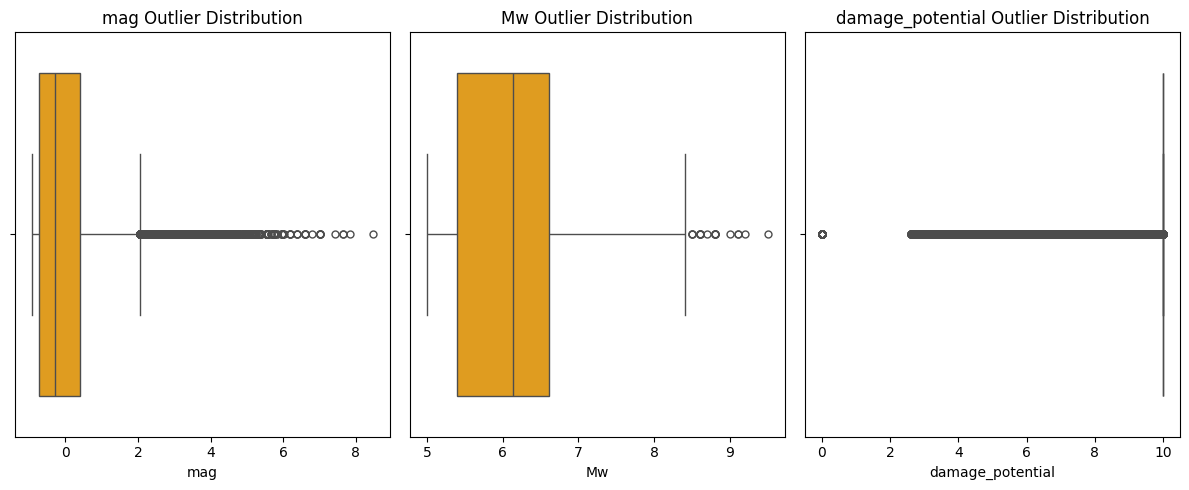


High-Risk Outlier Events (Top 5% Damage):


,mag,Mw,damage_potential
0,3.296720,7.02,10.0
1,2.920854,6.84,10.0
2,4.716657,7.70,10.0
3,4.299028,7.50,10.0
4,3.442890,7.09,10.0
5,3.860518,7.29,10.0
6,2.670277,6.72,10.0
7,2.190004,6.49,10.0
8,2.712040,6.74,10.0
9,2.231767,6.51,10.0


In [25]:
# Check main columns
cols = ['mag', 'Mw', 'damage_potential']
df = df[[col for col in cols if col in df.columns] + [c for c in ['Latitude','Longitude','Depth'] if c in df.columns]]

# Detect outliers using IQR method
outlier_info = {}
for col in ['mag', 'Mw', 'damage_potential']:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_info[col] = {
            "count": len(outliers),
            "percentage": round(len(outliers)/len(df)*100, 2),
            "lower_bound": lower,
            "upper_bound": upper
        }

        print(f"\n🔹 {col} Outliers:")
        print(f"   ➤ Count       : {outlier_info[col]['count']}")
        print(f"   ➤ Percentage  : {outlier_info[col]['percentage']}%")
        print(f"   ➤ Bounds      : [{lower:.2f}, {upper:.2f}]")

# Visualize with Boxplots
plt.figure(figsize=(12, 5))
for i, col in enumerate(['mag', 'Mw', 'damage_potential']):
    if col in df.columns:
        plt.subplot(1, 3, i+1)
        sns.boxplot(x=df[col], color='orange', fliersize=5)
        plt.title(f"{col} Outlier Distribution")
plt.tight_layout()
plt.show()

# Display characteristics of high-damage events ---
if 'damage_potential' in df.columns:
    threshold = df['damage_potential'].quantile(0.95)
    extreme_events = df[df['damage_potential'] >= threshold]
    print("\nHigh-Risk Outlier Events (Top 5% Damage):")
    display(extreme_events.head(10))

#### Task 4: Depth Analysis and Its Impact
Investigate how depth influences seismic characteristics and damage.


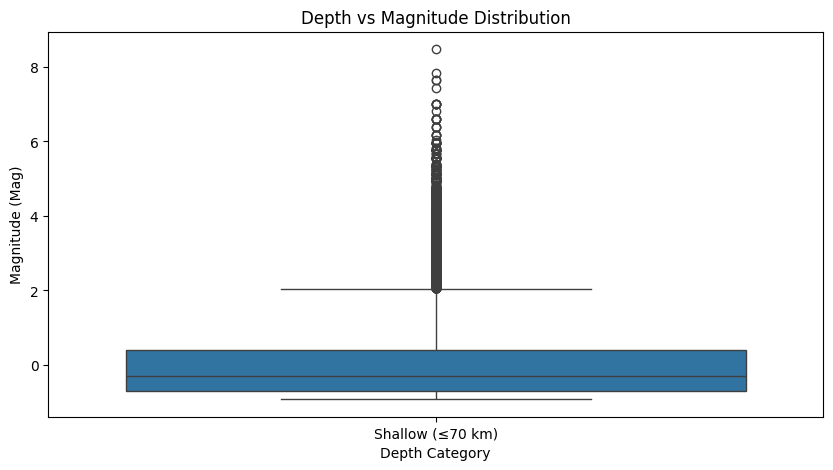

In [30]:
# Ensure required columns exist
required_cols = ['depth', 'mag', 'damage_potential']
df = df[[col for col in required_cols if col in df.columns]]

# Define Depth Categories 
def categorize_depth(depth):
    if depth <= 70:
        return 'Shallow (≤70 km)'
    elif 70 < depth <= 300:
        return 'Intermediate (70–300 km)'
    else:
        return 'Deep (>300 km)'

df['Depth_Category'] = df['depth'].apply(categorize_depth)

# Depth Category vs Magnitude ---
plt.figure(figsize=(10, 5))
sns.boxplot(x='Depth_Category', y='mag', data=df)
plt.title('Depth vs Magnitude Distribution')
plt.xlabel('Depth Category')
plt.ylabel('Magnitude (Mag)')
plt.show()

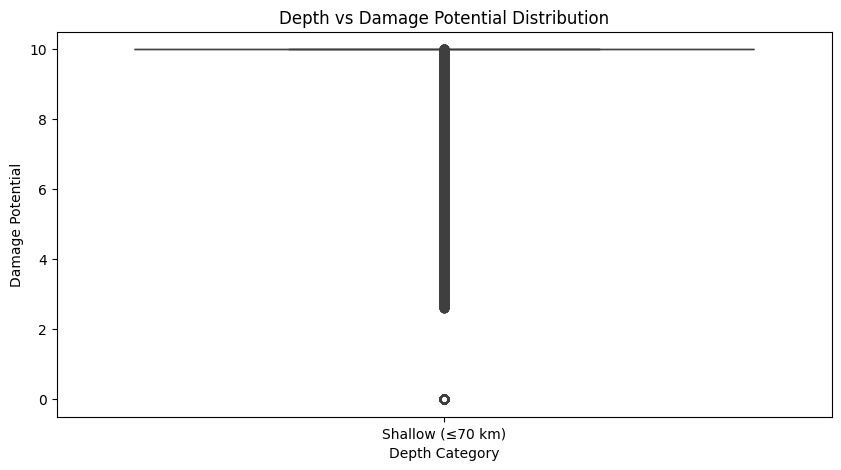

In [31]:
#  Boxplot: Depth Category vs Damage_Potential 
if 'damage_potential' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='Depth_Category', y='damage_potential', data=df)
    plt.title('Depth vs Damage Potential Distribution')
    plt.xlabel('Depth Category')
    plt.ylabel('Damage Potential')
    plt.show()


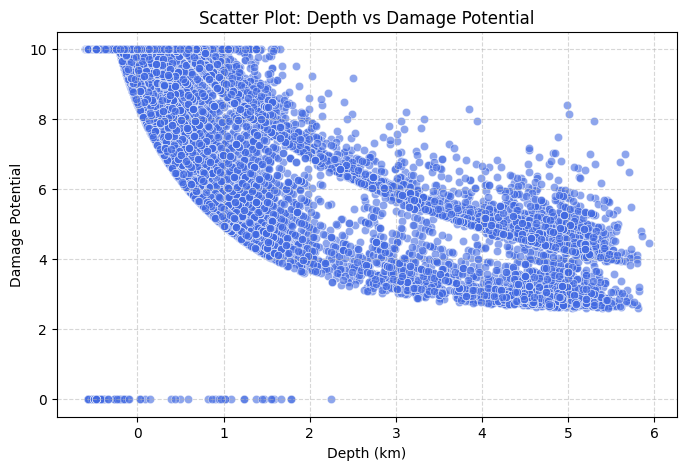

In [32]:
# Check if required columns exist
if 'depth' in df.columns and 'damage_potential' in df.columns:
    
# Scatter Plot: Depth vs Damage_Potential ---
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=df,
        x='depth',
        y='damage_potential',
        alpha=0.6,
        color='royalblue'
    )
    plt.title('Scatter Plot: Depth vs Damage Potential')
    plt.xlabel('Depth (km)')
    plt.ylabel('Damage Potential')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

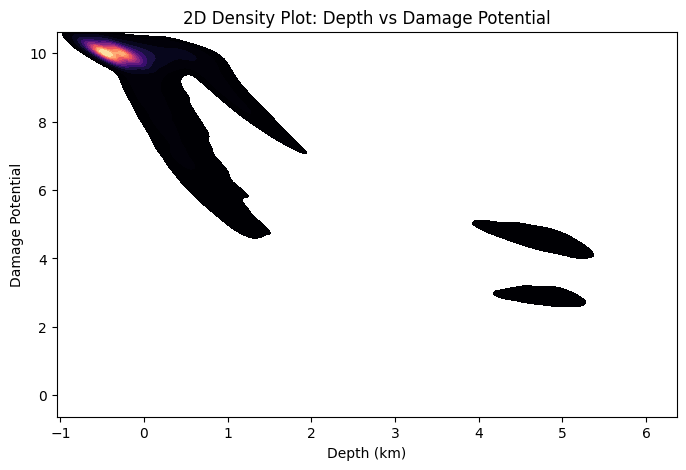

In [33]:
 # 2D Density Plot (KDE) 
plt.figure(figsize=(8, 5))
sns.kdeplot(
        data=df,
        x='depth',
        y='damage_potential',
        fill=True,
        cmap='magma',
        thresh=0.05,
        levels=15
    )
plt.title('2D Density Plot: Depth vs Damage Potential')
plt.xlabel('Depth (km)')
plt.ylabel('Damage Potential')
plt.show()

In [34]:
# Ensure required columns exist
if 'depth' in df.columns and 'damage_potential' in df.columns:

    # Categorize earthquakes based on depth 
    def categorize_depth(depth):
        if depth <= 70:
            return 'Shallow (≤70 km)'
        elif 70 < depth <= 300:
            return 'Intermediate (70–300 km)'
        else:
            return 'Deep (>300 km)'

    df['Depth_Category'] = df['depth'].apply(categorize_depth)

In [35]:
 # Calculate mean damage potential for each depth category
depth_damage_summary = (
        df.groupby('Depth_Category')['damage_potential']
        .mean()
        .round(2)
        .reset_index()
        .sort_values(by='damage_potential', ascending=False)
    )

print("Mean Damage Potential by Depth Range:")
print(depth_damage_summary)


Mean Damage Potential by Depth Range:
     Depth_Category  damage_potential
0  Shallow (≤70 km)               9.5


In [36]:
# Ensure required columns exist
if 'depth' in df.columns and 'damage_potential' in df.columns:

    # Categorize earthquakes by depth 
    def categorize_depth(depth):
        if depth <= 70:
            return 'Shallow (≤70 km)'
        elif 70 < depth <= 300:
            return 'Intermediate (70–300 km)'
        else:
            return 'Deep (>300 km)'

    df['Depth_Category'] = df['depth'].apply(categorize_depth)

In [37]:
 # Compute average damage potential per depth category

depth_damage_summary = (
        df.groupby('Depth_Category')['damage_potential']
        .mean()
        .round(2)
        .reset_index()
        .sort_values(by='damage_potential', ascending=False)
    )
print("Mean Damage Potential by Depth Category:")
print(depth_damage_summary)


Mean Damage Potential by Depth Category:
     Depth_Category  damage_potential
0  Shallow (≤70 km)               9.5


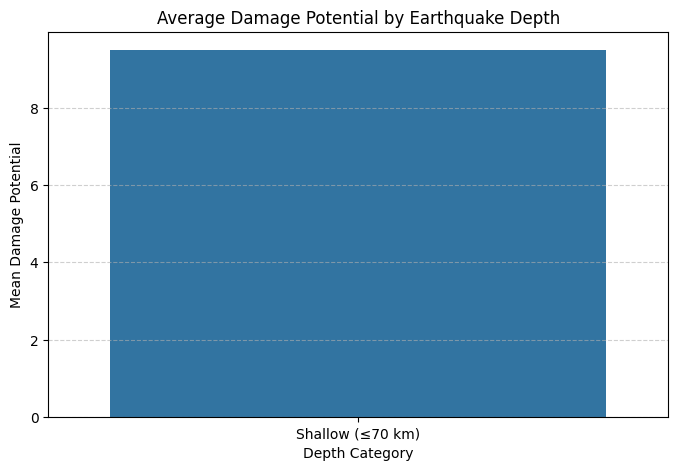

In [38]:
plt.figure(figsize=(8, 5))
sns.barplot(
        data=depth_damage_summary,
        x='Depth_Category',
        y='damage_potential',
     
    )
plt.title('Average Damage Potential by Earthquake Depth')
plt.xlabel('Depth Category')
plt.ylabel('Mean Damage Potential')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#### Task 5: Categorical Feature Analysis
Explore relationships between earthquake types, magnitude types, and status.

In [37]:
# Analyze value counts for magType, type, and status 
categorical_columns = ['magType', 'type', 'status']

for col in categorical_columns:
    if col in df.columns:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts(dropna=False))
    else:
        print(f"Column '{col}' not found in dataset.")


Value counts for magType:
magType
mb            45084
mw            24335
mwc           17458
mww           15652
ms             3157
mwb            3082
ml              485
mwr             451
md               50
mh               23
m                21
Mi               12
mwp               9
uk                8
fa                5
ml(texnet)        4
ms_20             3
mc                2
lg                1
mb_lg             1
ma                1
mlg               1
Md                1
Ml                1
Mb                1
Name: count, dtype: int64

Value counts for type:
type
earthquake           109356
nuclear explosion       424
volcanic eruption        54
explosion                10
landslide                 2
mine collapse             1
rock burst                1
Name: count, dtype: int64

Value counts for status:
status
reviewed     109744
automatic       104
Name: count, dtype: int64


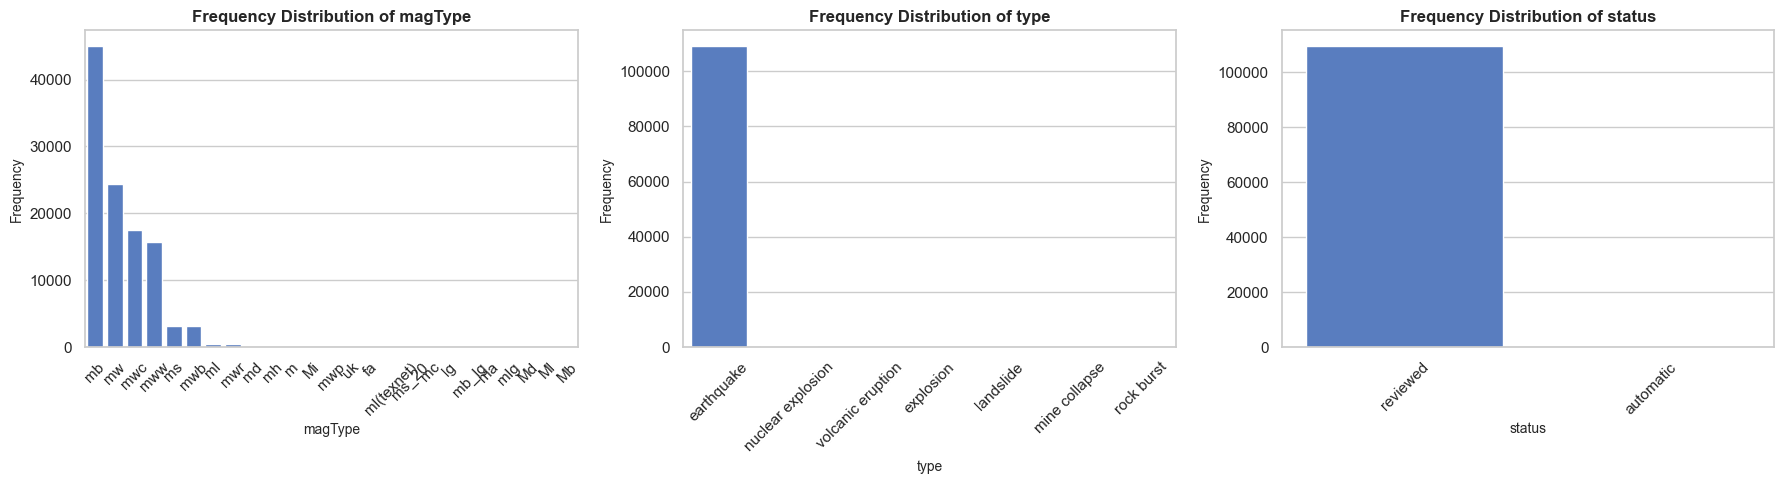

In [ ]:
# Select categorical columns
categorical_columns = ['magType', 'type', 'status']

plt.figure(figsize=(18, 5))

# Loop through each categorical feature to create bar chart
for i, col in enumerate(categorical_columns, 1):
    if col in df.columns:
        plt.subplot(1, 3, i)
        category_counts = df[col].value_counts()
        sns.barplot(
            x=category_counts.index,
            y=category_counts.values,
        )
        plt.title(f'Frequency Distribution of {col}', fontsize=12, weight='bold')
        plt.xlabel(col, fontsize=10)
        plt.ylabel('Frequency', fontsize=10)
        plt.xticks(rotation=45)
    else:
        print(f"Column '{col}' not found in dataset.")

plt.tight_layout()
plt.show()

In [20]:
# Check required columns
if all(col in df.columns for col in ['magType', 'mag', 'damage_potential']):
    
    # Compute mean values for each magnitude type
    grouped = df.groupby('magType')[['mag', 'damage_potential']].mean().reset_index()

    # Melt data for grouped bar plot (to plot both metrics side by side)
    grouped_melted = pd.melt(
        grouped,
        id_vars='magType',
        value_vars=['mag', 'damage_potential'],
        var_name='Metric',
        value_name='Mean_Value'
    )


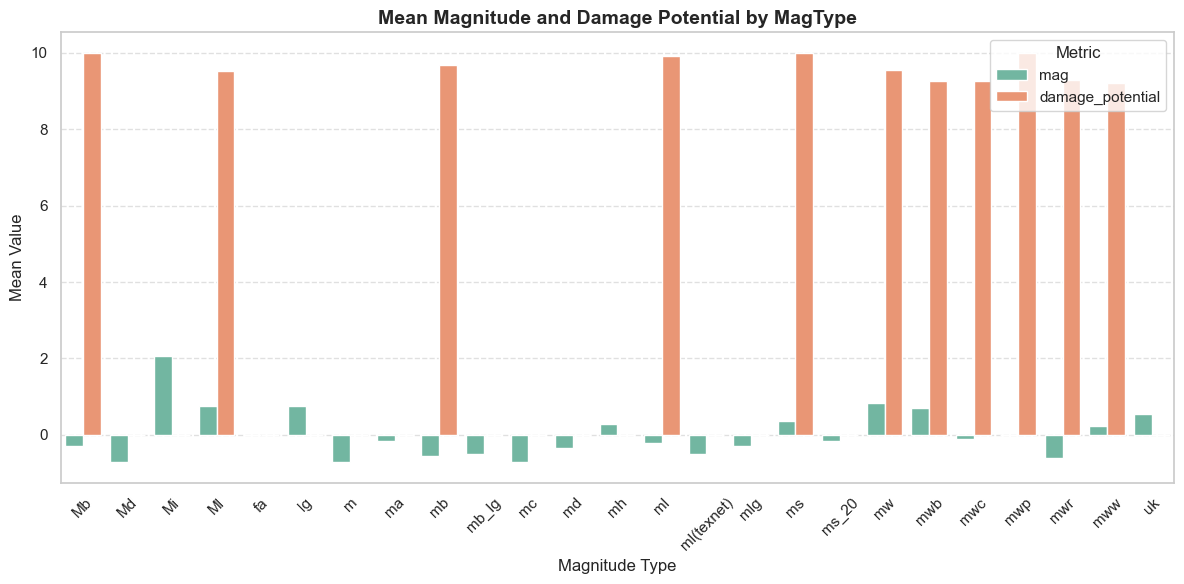

In [23]:
# Plot grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
        data=grouped_melted,
        x='magType',
        y='Mean_Value',
        hue='Metric',
        palette='Set2'
    )
plt.title('Mean Magnitude and Damage Potential by MagType', fontsize=14, weight='bold')
plt.xlabel('Magnitude Type', fontsize=12)
plt.ylabel('Mean Value', fontsize=12)
plt.legend(title='Metric', loc='upper right')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [38]:
# Ensure required categorical columns exist
cat_cols = ['magType', 'type', 'status']
available = [col for col in cat_cols if col in df.columns]

if len(available) == 3:
    # Cross-tab 1: magType vs Type
    crosstab_magtype_type = pd.crosstab(df['magType'], df['type'])
    print("\n Crosstab: magType vs Type\n")
    print(crosstab_magtype_type)

    # Cross-tab 2: magType vs Status
    crosstab_magtype_status = pd.crosstab(df['magType'], df['status'])
    print("\n Crosstab: magType vs Status\n")
    print(crosstab_magtype_status)

    # Cross-tab 3: Type vs Status
    crosstab_type_status = pd.crosstab(df['type'], df['status'])
    print("\nCrosstab: Type vs Status\n")
    print(crosstab_type_status)

    # Optional: include proportions to show relative distribution
    print("\n Normalized Crosstab (Type vs Status) — Row Percentages\n")
    print(pd.crosstab(df['type'], df['status'], normalize='index').round(2))


 Crosstab: magType vs Type

type        earthquake  explosion  landslide  mine collapse  \
magType                                                       
Mb                   1          0          0              0   
Md                   1          0          0              0   
Mi                  12          0          0              0   
Ml                   1          0          0              0   
fa                   5          0          0              0   
lg                   1          0          0              0   
m                   21          0          0              0   
ma                   1          0          0              0   
mb               44669         10          0              0   
mb_lg                1          0          0              0   
mc                   2          0          0              0   
md                  50          0          0              0   
mh                  23          0          0              0   
ml                 467    

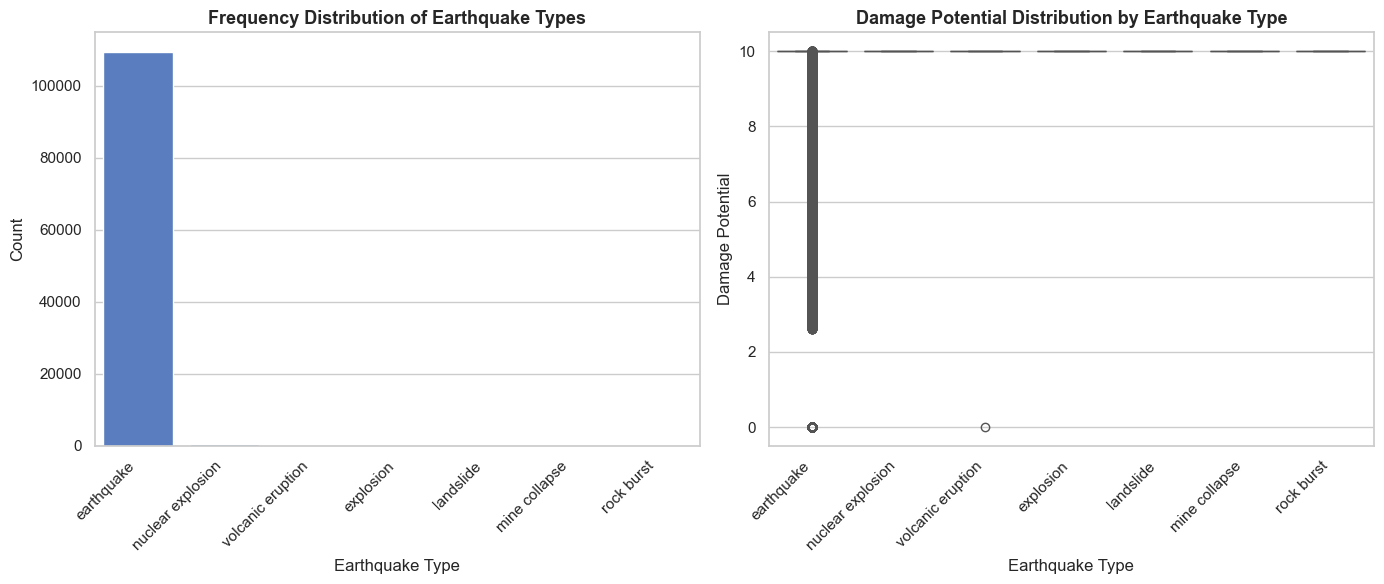

In [31]:
if all(col in df.columns for col in ['type', 'damage_potential']):
    
    plt.figure(figsize=(14, 6))

    # Plot 1: Frequency of Earthquake Types 
    plt.subplot(1, 2, 1)
    sns.countplot(data=df, x='type', order=df['type'].value_counts().index)
    plt.title('Frequency Distribution of Earthquake Types', fontsize=13, weight='bold')
    plt.xlabel('Earthquake Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

    # Plot 2: Damage Potential by Type (Boxplot)
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, x='type', y='damage_potential', order=df['type'].value_counts().index)
    plt.title('Damage Potential Distribution by Earthquake Type', fontsize=13, weight='bold')
    plt.xlabel('Earthquake Type')
    plt.ylabel('Damage Potential')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()


In [32]:
summary = df.groupby('type')['damage_potential'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False)
print("\n🔹 Summary: Average Damage Potential by Earthquake Type\n")
print(summary.round(2))


🔹 Summary: Average Damage Potential by Earthquake Type

                    mean  median   count
type                                    
explosion          10.00    10.0      10
landslide          10.00    10.0       2
mine collapse      10.00    10.0       1
rock burst         10.00    10.0       1
nuclear explosion  10.00    10.0     424
volcanic eruption   9.81    10.0      54
earthquake          9.50    10.0  109356


In [36]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Bias correction
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Ensure columns exist
cat_cols = ['magType', 'type', 'status']
available = [col for col in cat_cols if col in df.columns]

if len(available) == 3:
    # Calculate pairwise Cramér’s V values
    results = []
    pairs = [('magType', 'type'), ('magType', 'status'), ('type', 'status')]
    for x, y in pairs:
        value = cramers_v(df[x], df[y])
        results.append({'Variable 1': x, 'Variable 2': y, "Cramer's V": round(value, 3)})

    result_df = pd.DataFrame(results)
    print("\n Cramér's V Association Between Categorical Variables\n")
    print(result_df)


 Cramér's V Association Between Categorical Variables

  Variable 1 Variable 2  Cramer's V
0    magType       type       0.050
1    magType     status       0.059
2       type     status       0.000
